#**AML LAB**

##**Experiment 11**

### To predict whether a person has diabetes based on features such as blood pressure, skin thickness, age, etc., using the bagging ensemble technique. Also perform comparative analysis among the bagging classifier, random forest, and the decision tree classifier.

###1. Import Libraries

In [ ]:
# Core Libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#F44336', '#4CAF50']

# Scikit-learn: Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Scikit-learn: Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Scikit-learn: Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)

print("All libraries imported successfully.")

All libraries imported successfully.


### 2. Load Dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Applied_ML_Lab/Lab_8/dataset_diabetes_exp_11.csv')

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Dataset loaded: 768 rows × 9 columns

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 3. Exploratory Data Analysis (EDA)

In [ ]:
print("DATASET SHAPE:", df.shape)

print("\n── Column Data Types & Null Counts ──")
print(df.info())

print("\nStatistical Description")
df.describe().T

DATASET SHAPE: (768, 9)

── Column Data Types & Null Counts ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Statistical Description


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


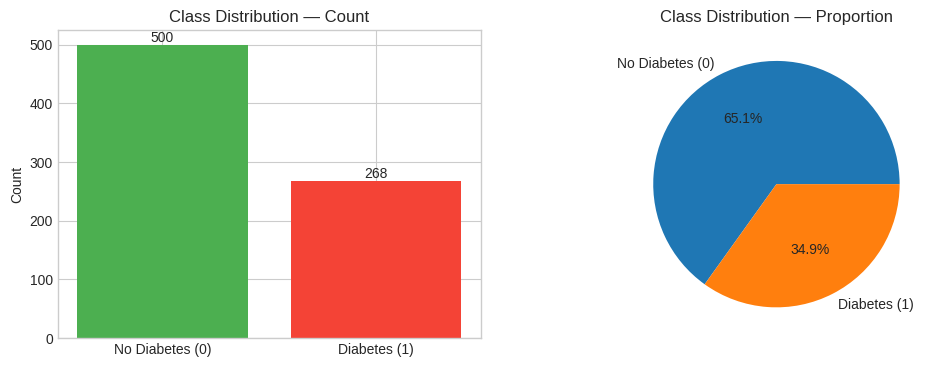


Class Ratio: 500 : 268


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Outcome'].value_counts()
labels = ['No Diabetes (0)', 'Diabetes (1)']

axes[0].bar(labels, counts.values, color=['#4CAF50', '#F44336'])
axes[0].set_title('Class Distribution — Count')
axes[0].set_ylabel('Count')

for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%')
axes[1].set_title('Class Distribution — Proportion')

plt.show()

print(f"\nClass Ratio: {counts[0]} : {counts[1]}")

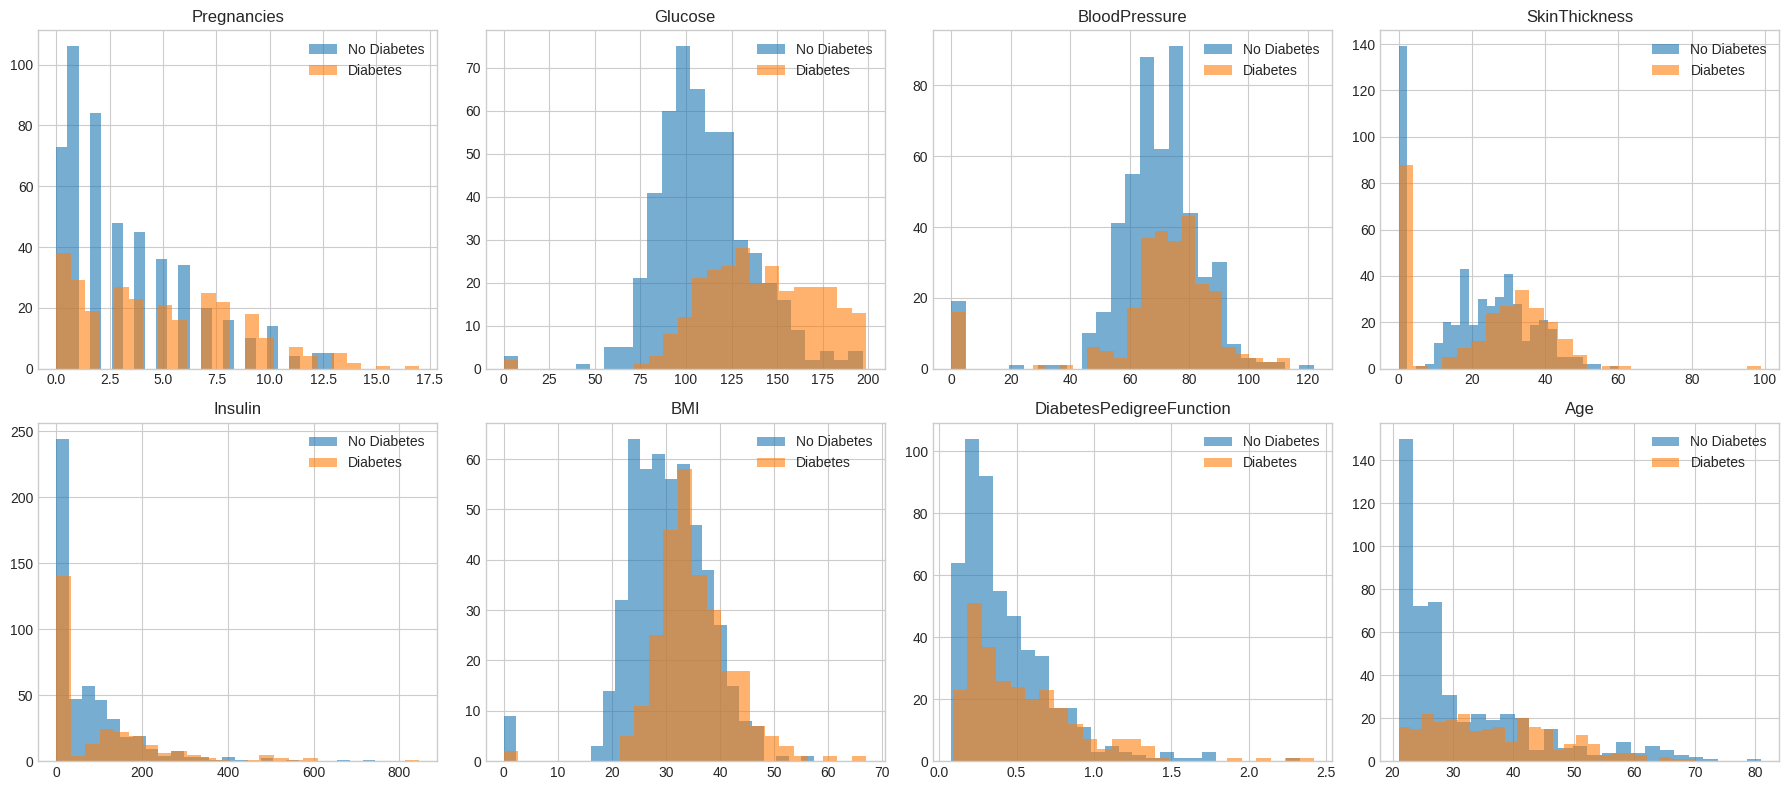

In [ ]:
features = [c for c in df.columns if c != 'Outcome']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, col in enumerate(features):
    axes[i].hist(df[df['Outcome'] == 0][col], bins=25, alpha=0.6, label='No Diabetes')
    axes[i].hist(df[df['Outcome'] == 1][col], bins=25, alpha=0.6, label='Diabetes')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

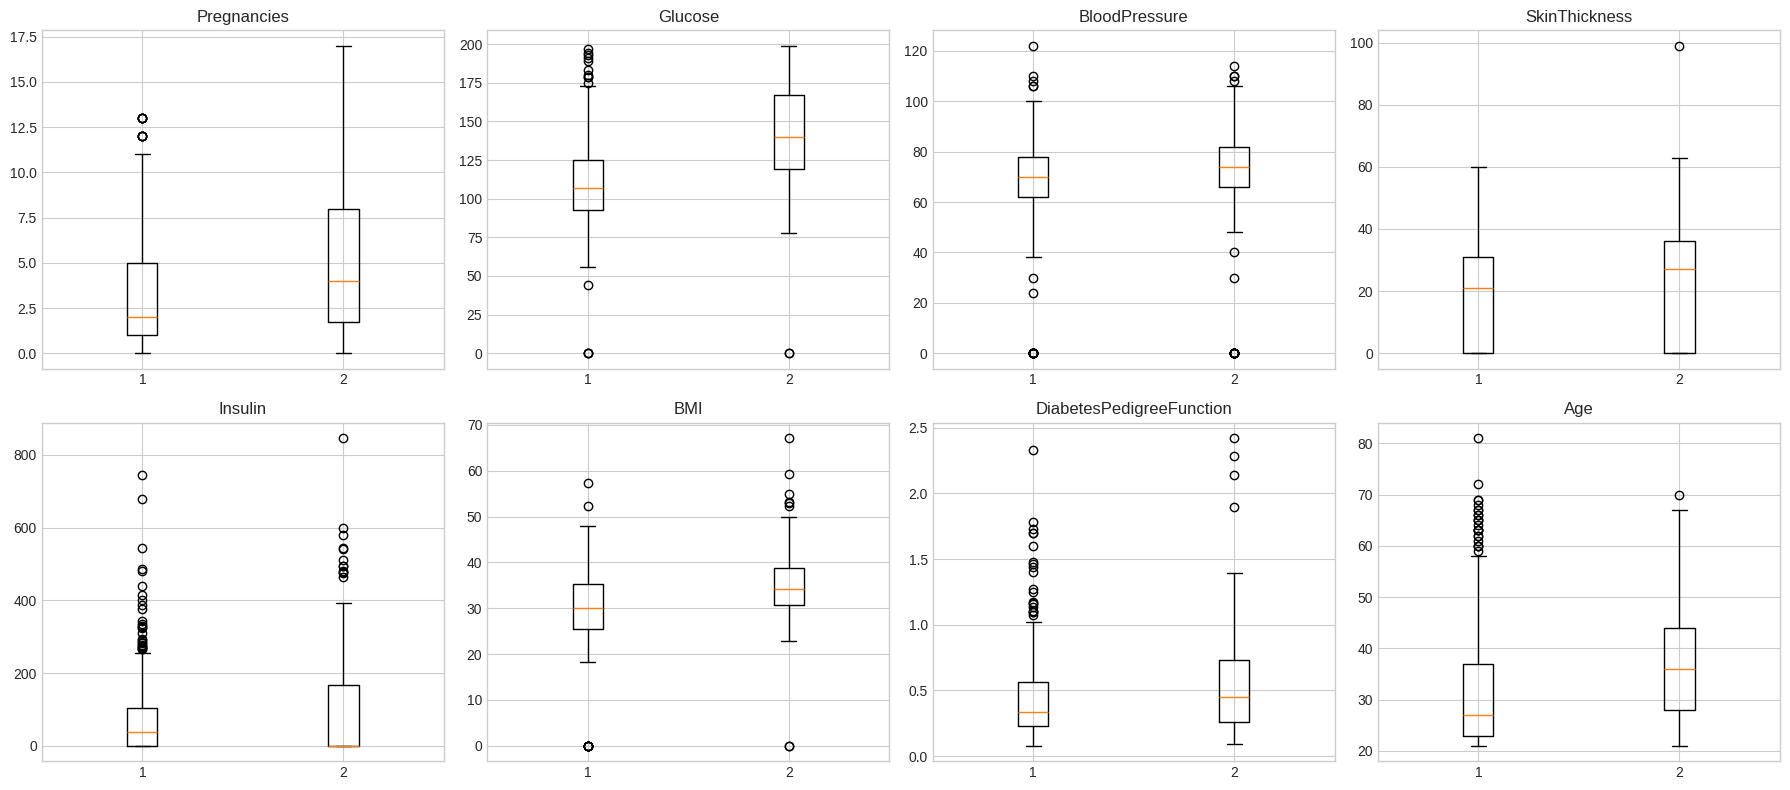

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, col in enumerate(features):
    axes[i].boxplot([df[df['Outcome']==0][col], df[df['Outcome']==1][col]])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

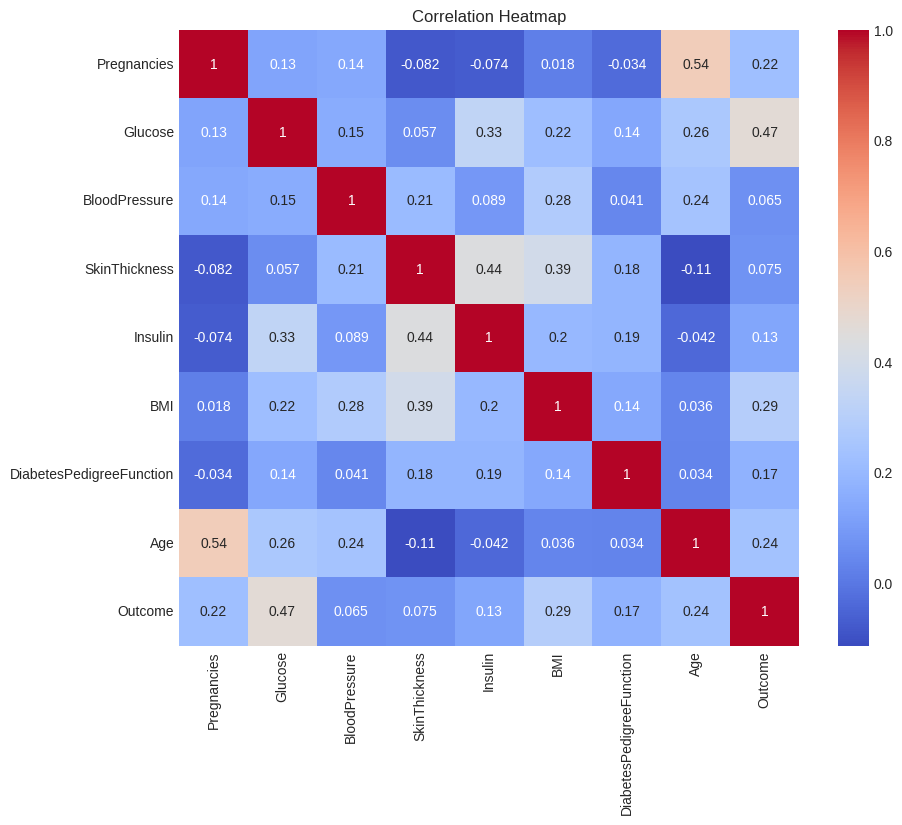


Top correlations with Outcome:
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [ ]:
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

print("\nTop correlations with Outcome:")
print(corr['Outcome'].sort_values(ascending=False))

###4. Data Preprocessing

In [ ]:
# 4.1 Identify & Treat Invalid Zero Values
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Zero counts before treatment:")
print(df[zero_cols].eq(0).sum())

df_clean = df.copy()

for col in zero_cols:
    median_val = df_clean[df_clean[col] != 0][col].median()
    df_clean[col] = df_clean[col].replace(0, median_val)
    print(f"  {col}: zeros → median ({median_val:.2f})")

print("\nZero counts after treatment:")
print(df_clean[zero_cols].eq(0).sum())
print("\nZero imputation complete.")

Zero counts before treatment:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64
  Glucose: zeros → median (117.00)
  BloodPressure: zeros → median (72.00)
  SkinThickness: zeros → median (29.00)
  Insulin: zeros → median (125.00)
  BMI: zeros → median (32.30)

Zero counts after treatment:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Zero imputation complete.


In [ ]:
# 4.2 Outlier Handling via IQR Capping

outlier_features = features
outlier_counts = {}

for col in outlier_features:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    count = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_counts[col] = count
    df_clean[col] = df_clean[col].clip(lower, upper)

print("Outliers detected and capped (IQR method):")
for col, cnt in outlier_counts.items():
    print(f"  {col}: {cnt} outlier(s) capped")

print(f"\nDataset shape after preprocessing: {df_clean.shape}")
print("Outlier treatment complete.")

Outliers detected and capped (IQR method):
  Pregnancies: 4 outlier(s) capped
  Glucose: 0 outlier(s) capped
  BloodPressure: 14 outlier(s) capped
  SkinThickness: 87 outlier(s) capped
  Insulin: 346 outlier(s) capped
  BMI: 8 outlier(s) capped
  DiabetesPedigreeFunction: 29 outlier(s) capped
  Age: 9 outlier(s) capped

Dataset shape after preprocessing: (768, 9)
Outlier treatment complete.


### 5. Feature Engineering

In [ ]:
# Feature / Target Split
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

print("Feature matrix X:", X.shape)
print("Target vector y:", y.shape)
print("\nFeatures used:", list(X.columns))

Feature matrix X: (768, 8)
Target vector y: (768,)

Features used: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


### 6. Train-Test Split

In [ ]:
# Stratified 80/20 split preserves class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nTrain class distribution: {y_train.value_counts().to_dict()}")
print(f"Test  class distribution: {y_test.value_counts().to_dict()}")
print("\nStratified split ensures class proportions are preserved in both sets.")

Training set : 614 samples
Test set     : 154 samples

Train class distribution: {0: 400, 1: 214}
Test  class distribution: {0: 100, 1: 54}

Stratified split ensures class proportions are preserved in both sets.


###7. Model Training

In [ ]:
# Build Pipelines

# 0. Logistic Regression (Baseline — NEW)
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

# 1. Decision Tree (baseline)
pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        random_state=42
    ))
])

# 2. Bagging Classifier (base = Decision Tree)
pipe_bag = Pipeline([
    ('scaler', StandardScaler()),
    ('model', BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
        n_estimators=100,
        max_samples=0.8,
        max_features=0.8,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ))
])

# 3. Random Forest Classifier
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        min_samples_split=10,
        max_features='sqrt',   # standard RF: sqrt(n_features) at each split
        random_state=42,
        n_jobs=-1
    ))
])

# Train All Models
models = {
    'Logistic Regression': pipe_lr,
    'Decision Tree': pipe_dt,
    'Bagging Classifier': pipe_bag,
    'Random Forest': pipe_rf
}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    print(f"{name} — trained.")

print("\nAll models trained successfully.")

Logistic Regression — trained.
Decision Tree — trained.
Bagging Classifier — trained.
Random Forest — trained.

All models trained successfully.


###8. Model Evaluation

In [ ]:
# Compute Metrics for All Models
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipe in models.items():
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    if name == 'Logistic Regression':
        cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
    else:
        cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')


    cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')

    results[name] = {
        'Accuracy'   : accuracy_score(y_test, y_pred),
        'Precision'  : precision_score(y_test, y_pred),
        'Recall'     : recall_score(y_test, y_pred),
        'F1 Score'   : f1_score(y_test, y_pred),
        'ROC-AUC'    : roc_auc_score(y_test, y_prob),
        'CV Accuracy': cv_scores.mean(),
        'CV Std'     : cv_scores.std(),
        'y_pred'     : y_pred,
        'y_prob'     : y_prob
    }

# Print Classification Reports
for name, res in results.items():
    print(f"\n{'='*55}")
    print(f" {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, res['y_pred'],
                                 target_names=['No Diabetes', 'Diabetes']))


 Logistic Regression
              precision    recall  f1-score   support

 No Diabetes       0.75      0.82      0.78       100
    Diabetes       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


 Decision Tree
              precision    recall  f1-score   support

 No Diabetes       0.85      0.78      0.81       100
    Diabetes       0.65      0.74      0.69        54

    accuracy                           0.77       154
   macro avg       0.75      0.76      0.75       154
weighted avg       0.78      0.77      0.77       154


 Bagging Classifier
              precision    recall  f1-score   support

 No Diabetes       0.79      0.84      0.81       100
    Diabetes       0.66      0.57      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.71       154
weighted avg   

###9. Visualizations

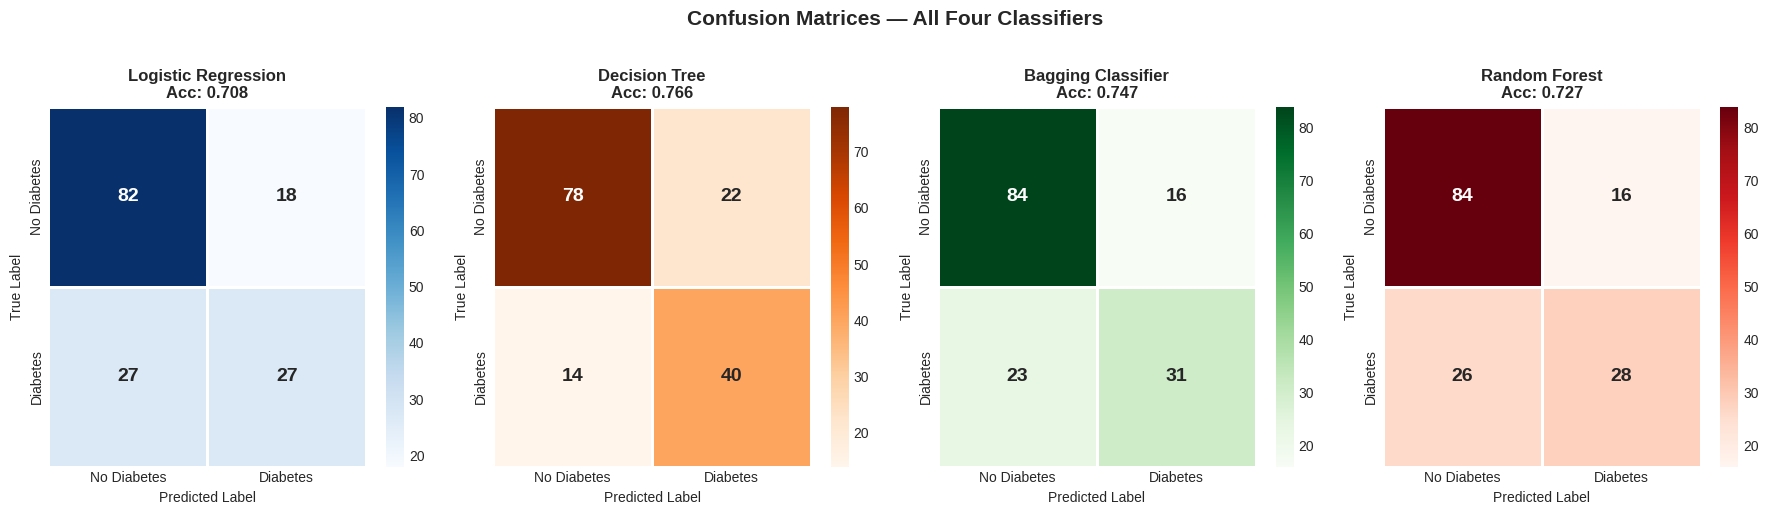

In [ ]:
# 9.1 Confusion Matrix Heatmaps
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = ['Blues', 'Oranges', 'Greens', 'Reds']

for ax, (name, res), cmap in zip(axes, results.items(), colors):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'],
                linewidths=1, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'{name}\nAcc: {res["Accuracy"]:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — All Four Classifiers', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

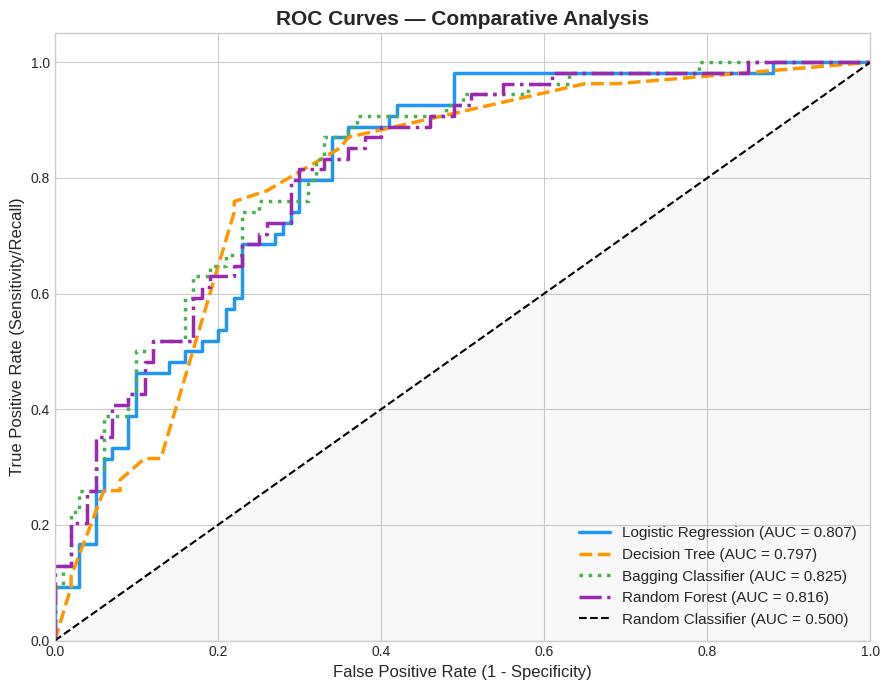

In [ ]:
# 9.2 ROC Curves (All Models in One Plot)
fig, ax = plt.subplots(figsize=(9, 7))

# Extended line styles and colors to accommodate all four models
line_styles = ['-', '--', ':', '-.']  # Added one more line style
model_colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0'] # Added one more color (Purple)

for (name, res), ls, color in zip(results.items(), line_styles, model_colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2.5, linestyle=ls, color=color,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=12)
ax.set_title('ROC Curves — Comparative Analysis', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

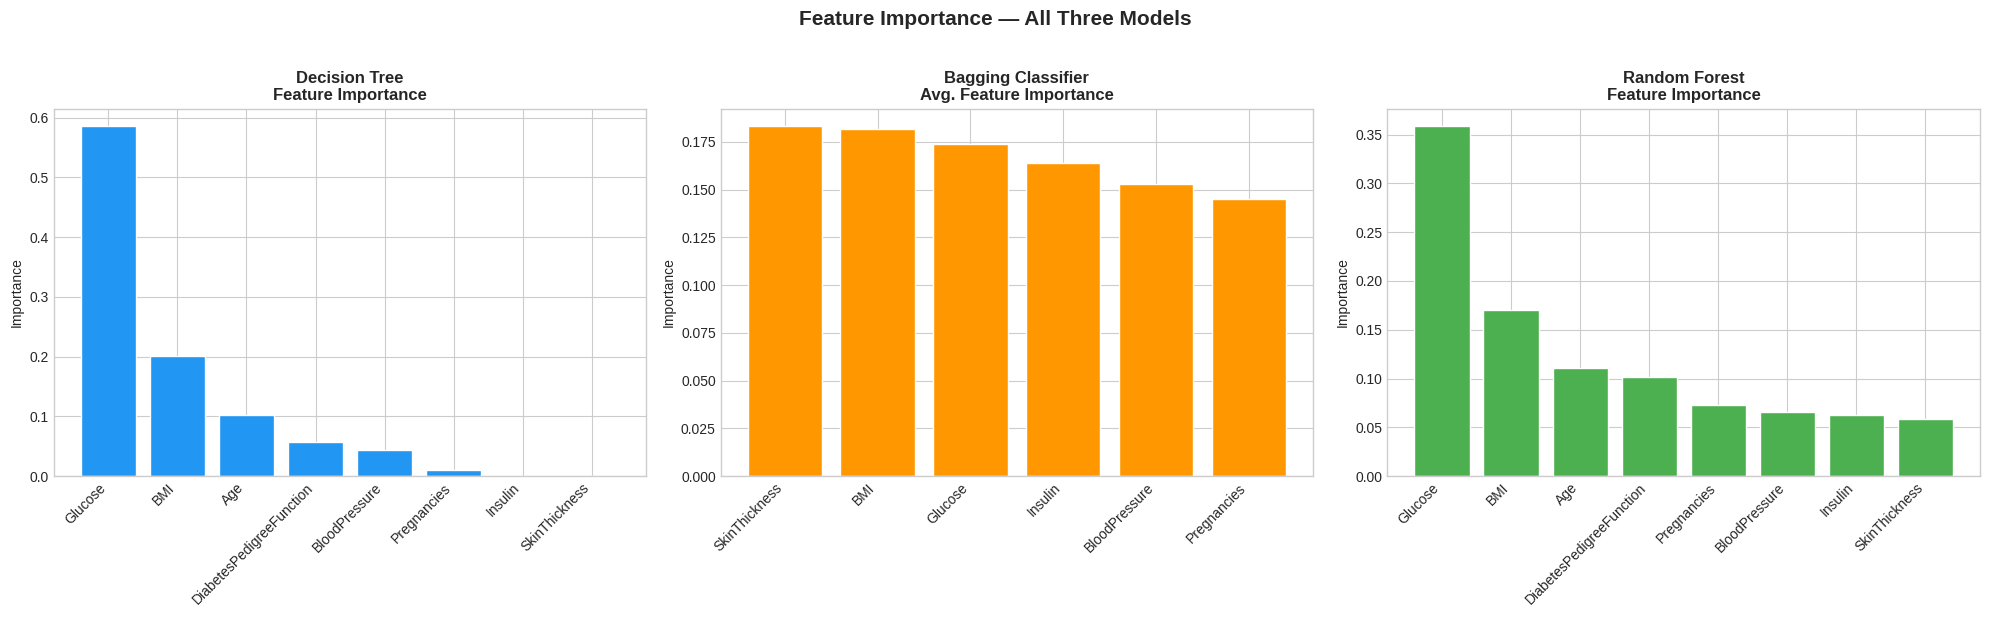

In [ ]:
# 9.3 Feature Importance Comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Decision Tree importance
dt_imp = pipe_dt.named_steps['model'].feature_importances_
idx_dt = np.argsort(dt_imp)[::-1]
axes[0].bar(range(len(dt_imp)), dt_imp[idx_dt], color='#2196F3', edgecolor='white')
axes[0].set_xticks(range(len(dt_imp)))
axes[0].set_xticklabels(X.columns[idx_dt], rotation=45, ha='right')
axes[0].set_title('Decision Tree\nFeature Importance', fontweight='bold')
axes[0].set_ylabel('Importance')

# Bagging — average over base estimators
bag_imps = np.array([est.feature_importances_ for est in pipe_bag.named_steps['model'].estimators_])
bag_imp  = bag_imps.mean(axis=0)
idx_bag  = np.argsort(bag_imp)[::-1]
axes[1].bar(range(len(bag_imp)), bag_imp[idx_bag], color='#FF9800', edgecolor='white')
axes[1].set_xticks(range(len(bag_imp)))
axes[1].set_xticklabels(X.columns[idx_bag], rotation=45, ha='right')
axes[1].set_title('Bagging Classifier\nAvg. Feature Importance', fontweight='bold')
axes[1].set_ylabel('Importance')

# Random Forest importance
rf_imp = pipe_rf.named_steps['model'].feature_importances_
idx_rf = np.argsort(rf_imp)[::-1]
axes[2].bar(range(len(rf_imp)), rf_imp[idx_rf], color='#4CAF50', edgecolor='white')
axes[2].set_xticks(range(len(rf_imp)))
axes[2].set_xticklabels(X.columns[idx_rf], rotation=45, ha='right')
axes[2].set_title('Random Forest\nFeature Importance', fontweight='bold')
axes[2].set_ylabel('Importance')

plt.suptitle('Feature Importance — All Three Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

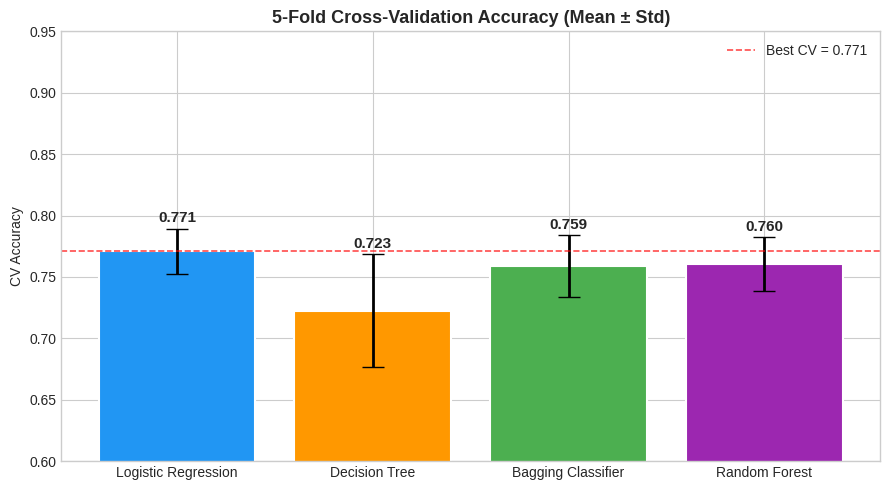

In [ ]:
# 9.4 Cross-Validation Score Comparison
fig, ax = plt.subplots(figsize=(9, 5))

model_names = list(results.keys())
cv_means = [results[m]['CV Accuracy'] for m in model_names]
cv_stds  = [results[m]['CV Std'] for m in model_names]

bars = ax.bar(model_names, cv_means, yerr=cv_stds, capsize=8,
              color=model_colors, edgecolor='white', linewidth=1.5,
              error_kw={'elinewidth': 2, 'ecolor': 'black'})

for bar, val, std in zip(bars, cv_means, cv_stds):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + 0.005,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylim(0.6, 0.95)
ax.set_title('5-Fold Cross-Validation Accuracy (Mean ± Std)', fontsize=13, fontweight='bold')
ax.set_ylabel('CV Accuracy')
ax.axhline(y=max(cv_means), color='red', linestyle='--', linewidth=1.2, alpha=0.7,
           label=f'Best CV = {max(cv_means):.3f}')
ax.legend()

plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 10. Model Comparison Table

In [ ]:
# Comprehensive Comparison Table
metric_keys = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'CV Accuracy']

comparison_df = pd.DataFrame(
    {name: {k: round(results[name][k], 4) for k in metric_keys} for name in results}
).T

# Highlight best value per column
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #c8e6c9; font-weight: bold' if v else '' for v in is_max]

print("\nMODEL COMPARISON TABLE (Best values highlighted in green)\n")
comparison_df.style.apply(highlight_max).format('{:.4f}')


MODEL COMPARISON TABLE (Best values highlighted in green)



,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV Accuracy
Logistic Regression,0.7078,0.6000,0.5000,0.5455,0.8074,0.7708
Decision Tree,0.7662,0.6452,0.7407,0.6897,0.7975,0.7225
Bagging Classifier,0.7468,0.6596,0.5741,0.6139,0.8248,0.7590
Random Forest,0.7273,0.6364,0.5185,0.5714,0.8156,0.7604


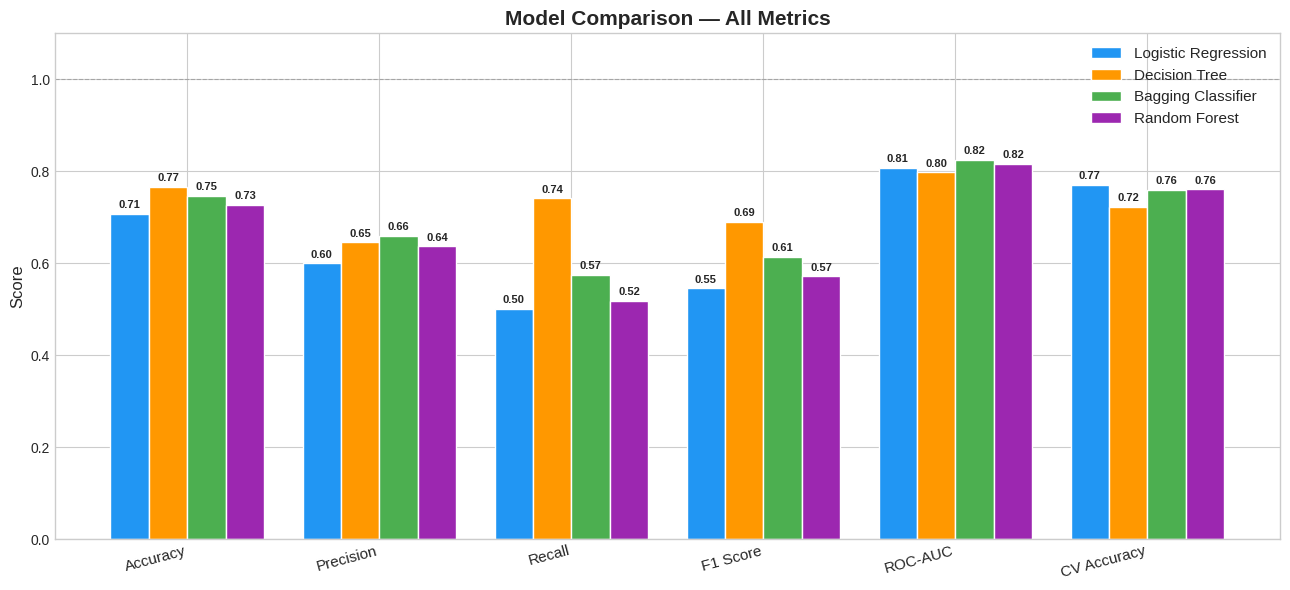

In [ ]:
# Grouped Bar Chart: All Metrics Side-by-Side
fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(metric_keys))
width = 0.20 # Reduced width to fit 4 bars

# Ensure model_colors has enough entries for all models
model_colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0'] # Re-defined to include a 4th color

for i, (name, color) in enumerate(zip(results.keys(), model_colors)):
    vals = [results[name][k] for k in metric_keys]
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=color, edgecolor='white', linewidth=1)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

ax.set_xticks(x + 1.5 * width) # Adjusted x-tick positions for centering
ax.set_xticklabels(metric_keys, rotation=15, ha='right', fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — All Metrics', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(y=1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 11. Conclusion & Analysis

In [ ]:
# Print Winner Summary
best_model = comparison_df['F1 Score'].idxmax()
best_f1    = comparison_df['F1 Score'].max()
best_auc   = comparison_df.loc[best_model, 'ROC-AUC']

print(f"BEST MODEL  :  {best_model:<26}")
print(f"F1 Score       :  {best_f1:.4f}")
print(f"ROC-AUC        :  {best_auc:.4f}")

print("\nComparison Summary")
print(comparison_df.to_string())

print("\nInsight:")
print("Decision Tree shows highest F1 due to dataset size, while ensembles generalize better (higher ROC-AUC & CV stability).")

BEST MODEL  :  Decision Tree             
F1 Score       :  0.6897
ROC-AUC        :  0.7975

Comparison Summary
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC  CV Accuracy
Logistic Regression    0.7078     0.6000  0.5000    0.5455   0.8074       0.7708
Decision Tree          0.7662     0.6452  0.7407    0.6897   0.7975       0.7225
Bagging Classifier     0.7468     0.6596  0.5741    0.6139   0.8248       0.7590
Random Forest          0.7273     0.6364  0.5185    0.5714   0.8156       0.7604

Insight:
Decision Tree shows highest F1 due to dataset size, while ensembles generalize better (higher ROC-AUC & CV stability).
